# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Heart Disease Dataset** dari UCI Machine Learning Repository.

- **Sumber**: [UCI ML Repository - Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)
- **Jumlah Data**: 303 baris, 13 fitur + 1 target
- **Task**: Binary Classification — memprediksi apakah pasien menderita penyakit jantung (1) atau tidak (0)
- **Fitur**: Campuran numerikal (age, trestbps, chol, thalach, oldpeak) dan kategorikal (sex, cp, fbs, restecg, exang, slope, ca, thal)
- **Missing Values**: Ada pada kolom `ca` dan `thal`

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [19]:
# Install package jika belum ada
!pip install ucimlrepo -q

# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Gabungkan fitur dan target
X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

# Rename kolom target agar lebih jelas
df.rename(columns={'num': 'target'}, inplace=True)

# Konversi target ke binary (0 = tidak sakit, 1 = sakit)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"Shape dataset: {df.shape}")
print(f"\n5 baris pertama:")
df.head()

Shape dataset: (303, 14)

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [20]:
# Simpan dataset raw sebelum diproses
df_raw = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)
df_raw.to_csv('heart_disease_raw.csv', index=False)
print("Dataset raw berhasil disimpan!")

Dataset raw berhasil disimpan!


In [21]:
print("=== INFO DATASET ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None

=== STATISTIK DESKRIPTIF ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [22]:
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])

=== MISSING VALUES ===
      Jumlah Missing  Persentase (%)
ca                 4        1.320132
thal               2        0.660066


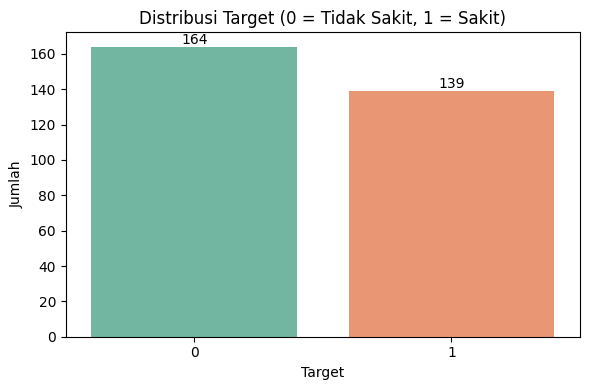

target
0    164
1    139
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribusi Target (0 = Tidak Sakit, 1 = Sakit)')
plt.xlabel('Target')
plt.ylabel('Jumlah')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['target'].value_counts())

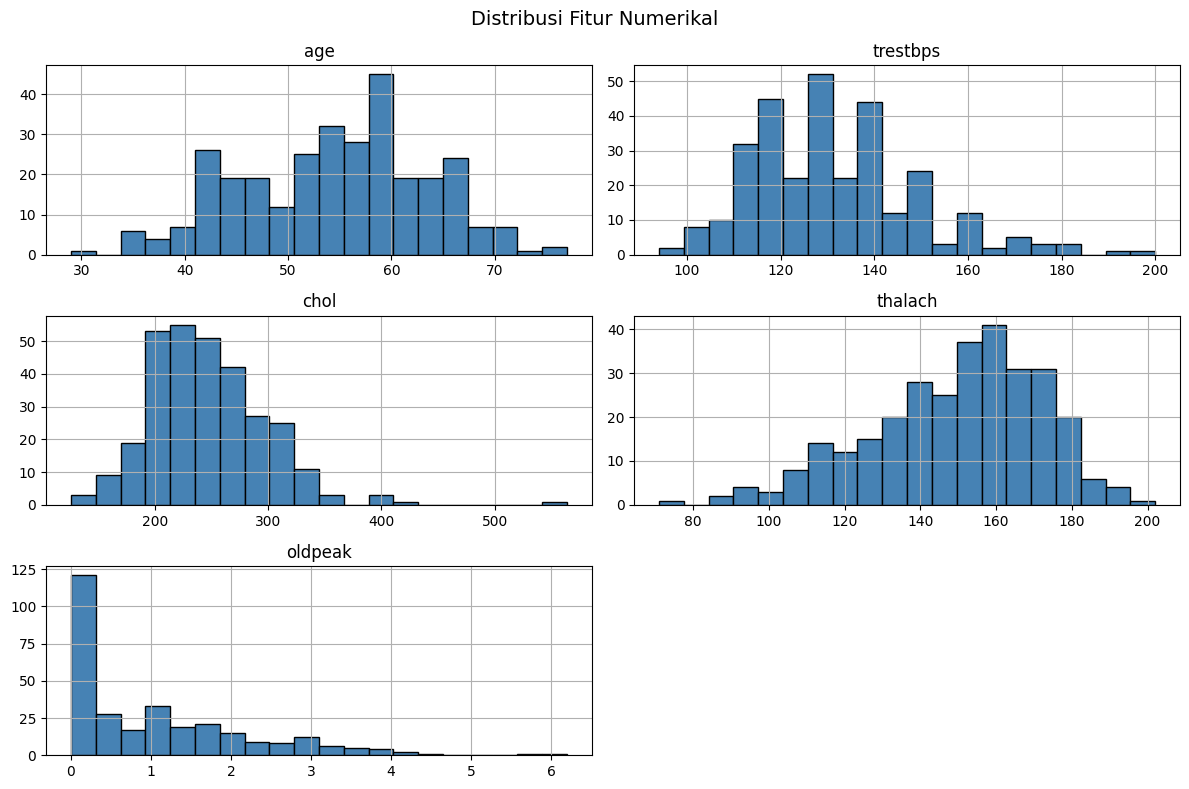

In [24]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df[numerical_cols].hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerikal', fontsize=14)
plt.tight_layout()
plt.show()

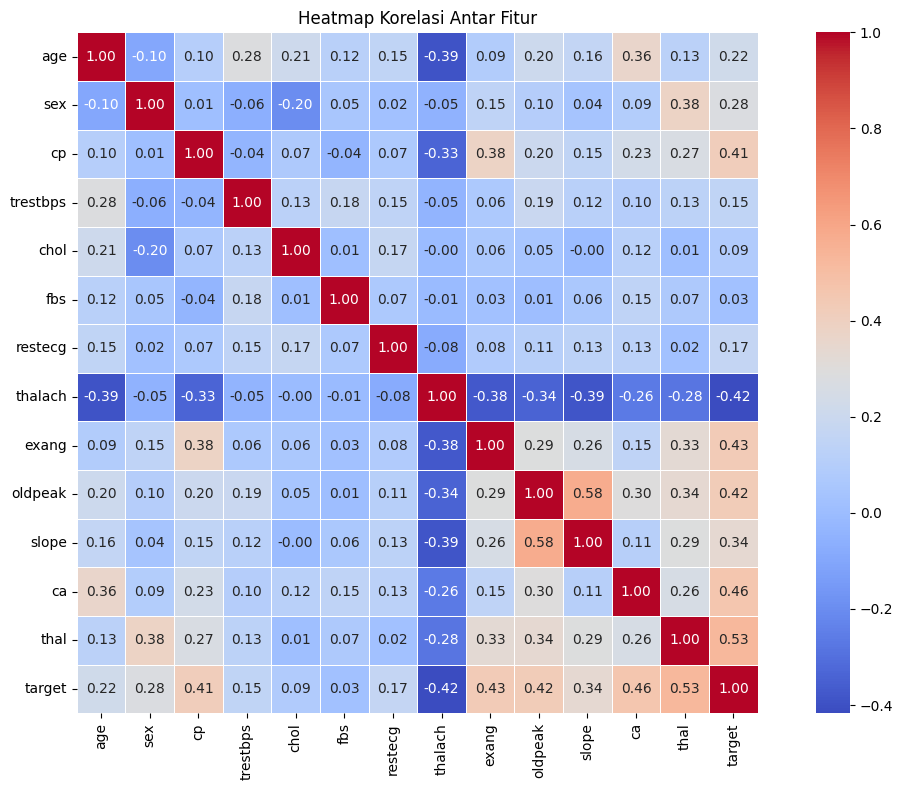

In [25]:
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

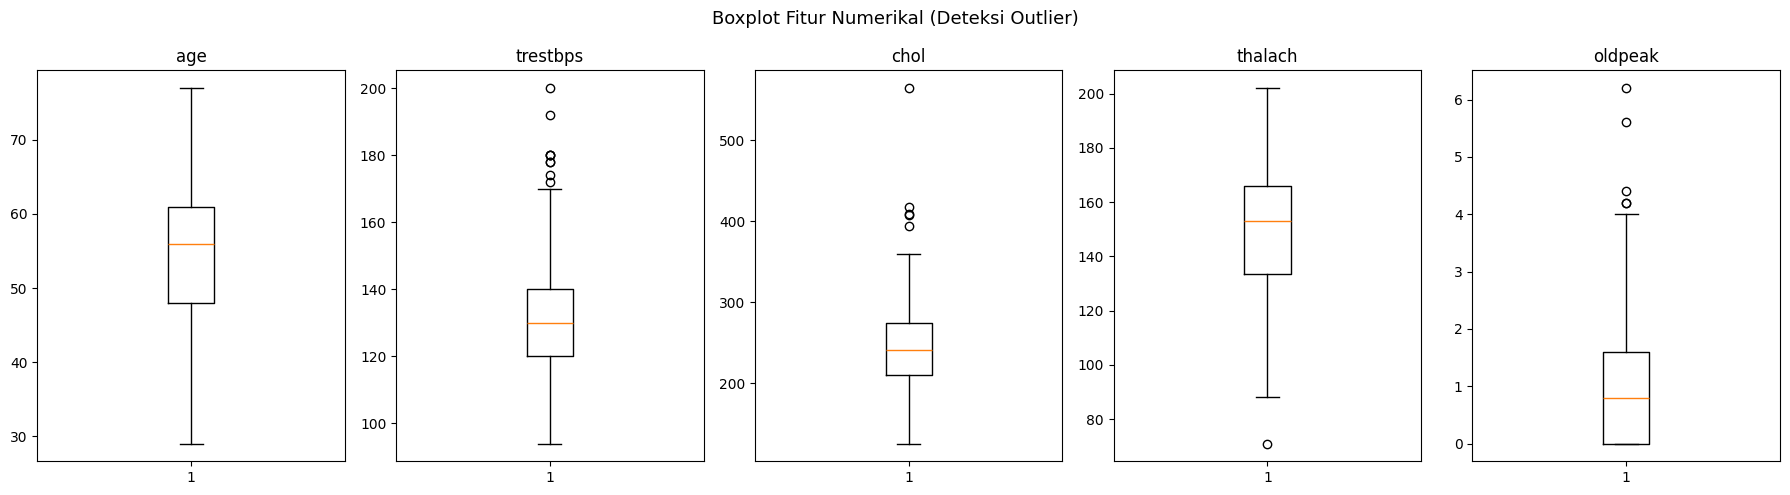

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Boxplot Fitur Numerikal (Deteksi Outlier)', fontsize=13)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [27]:
print("Missing values sebelum handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Isi missing values dengan median (robust terhadap outlier)
df['ca'].fillna(df['ca'].median(), inplace=True)
df['thal'].fillna(df['thal'].median(), inplace=True)

print("\nMissing values setelah handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Tidak ada missing values!" if df.isnull().sum().sum() == 0 else "")

Missing values sebelum handling:
ca      4
thal    2
dtype: int64

Missing values setelah handling:
Series([], dtype: int64)
Tidak ada missing values!


In [28]:
print(f"Jumlah duplikat: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape setelah hapus duplikat: {df.shape}")

Jumlah duplikat: 0
Shape setelah hapus duplikat: (303, 14)


In [29]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        after = len(df_clean)
        print(f"{col}: {before - after} baris dihapus")
    return df_clean

df = remove_outliers_iqr(df, numerical_cols)
print(f"\nShape setelah handle outlier: {df.shape}")

age: 0 baris dihapus
trestbps: 9 baris dihapus
chol: 5 baris dihapus
thalach: 1 baris dihapus
oldpeak: 4 baris dihapus

Shape setelah handle outlier: (284, 14)


In [30]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Shape setelah encoding: {df_encoded.shape}")
df_encoded.head()

Shape setelah encoding: (284, 21)


,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_2,cp_3,cp_4,...,restecg_1,restecg_2,exang_1,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,63,145,233,150,2.3,0,True,False,False,False,...,False,True,False,False,True,False,False,False,True,False
1,67,160,286,108,1.5,1,True,False,False,True,...,False,True,True,True,False,False,False,True,False,False
2,67,120,229,129,2.6,1,True,False,False,True,...,False,True,True,True,False,False,True,False,False,True
3,37,130,250,187,3.5,0,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,41,130,204,172,1.4,0,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False


In [31]:
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Scaling selesai. Statistik fitur numerikal setelah scaling:")
df_encoded[numerical_cols].describe().round(3)

Scaling selesai. Statistik fitur numerikal setelah scaling:


,age,trestbps,chol,thalach,oldpeak
count,284.000,284.000,284.000,284.000,284.000
mean,0.000,-0.000,0.000,0.000,0.000
std,1.002,1.002,1.002,1.002,1.002
min,-2.754,-2.333,-2.610,-2.741,-0.926
25%,-0.777,-0.647,-0.712,-0.718,-0.926
50%,0.102,0.001,-0.068,0.133,-0.340
75%,0.651,0.649,0.637,0.796,0.636
max,2.519,2.595,2.631,2.299,2.979


In [32]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (227, 20)
X_test shape  : (57, 20)
y_train shape : (227,)
y_test shape  : (57,)


In [33]:
# Gabungkan kembali untuk disimpan
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('heart_disease_preprocessing_train.csv', index=False)
test_df.to_csv('heart_disease_preprocessing_test.csv', index=False)

# Atau simpan semua jadi satu file
df_encoded.to_csv('heart_disease_preprocessing.csv', index=False)

print("Dataset preprocessing berhasil disimpan!")
print(f"File: heart_disease_preprocessing.csv ({df_encoded.shape[0]} baris, {df_encoded.shape[1]} kolom)")

Dataset preprocessing berhasil disimpan!
File: heart_disease_preprocessing.csv (284 baris, 21 kolom)
